## Importación de librerías

In [2]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_theme()


## Carga, agregación a 90 días y purga de datos sensibles

In [3]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_90_days = vle_df[vle_df['date'] <= 90]
vle_agg = vle_90_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [4]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [5]:
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

# Limpiar columnas de metadatos e identificadores
columnas_a_borrar = ['code_module', 'code_presentation']

# Separar matriz de características (X) y variable objetivo (y)
X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12192
Alumnos Nuevos (Test 2014): 16966


## Construcción y Entrenamiento del Pipeline

In [14]:

# Definición de columnas
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])


"""
 - class_weight: {0: 1, 1: 5}
 - max_depth: 10
 - min_samples_leaf: 1
 - n_estimators: 100
"""

# Pipeline Base Random Forest: 100 árboles y penalización manual para clase Riesgo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          class_weight={0: 1, 1: 5}, # Equivocarse en riesgo penaliza 10 veces más
                                          random_state=42,
                                          n_jobs=-1)) # n_jobs=-1 usa todos tus núcleos
])

# Entrenar modelo
rf_pipeline.fit(X_train, y_train)

# Generar predicciones (Mantenido intacto para que no se rompa la celda 6)
y_pred = rf_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

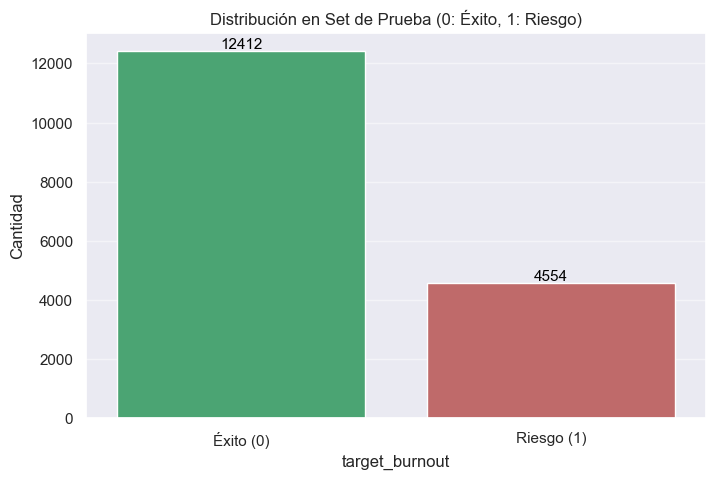

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.15) ---
              precision    recall  f1-score   support

           0       0.84      0.51      0.63     12412
           1       0.35      0.73      0.48      4554

    accuracy                           0.57     16966
   macro avg       0.60      0.62      0.56     16966
weighted avg       0.71      0.57      0.59     16966



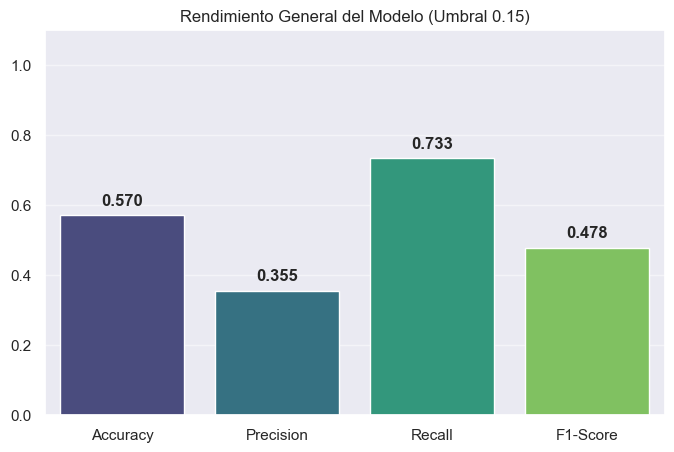

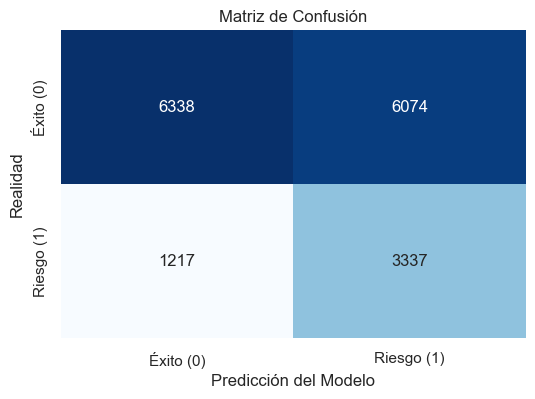

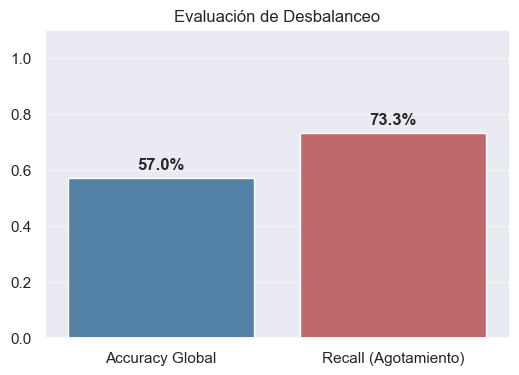

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# NUEVO: CÁLCULO DE PREDICCIONES POR UMBRAL (PARA SUBIR RECALL)
# ==========================================
# Obtenemos las probabilidades de la clase 1 (Riesgo).
# NOTA: Cambia 'nb_pipeline' por 'rf_pipeline' si estás en el script de Random Forest
y_probs = rf_pipeline.predict_proba(X_test)[:, 1]

# UMBRAL PERMISIVO: Ante un 30% de sospecha, clasifica como Riesgo (1).
umbral_permisivo = 0.15
y_pred = (y_probs >= umbral_permisivo).astype(int)

# ==========================================
# GRÁFICO 1: Distribución en el Set de Prueba
# ==========================================
fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICO 2: Visualización de Métricas Habituales
# ==========================================
fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# ==========================================
# GRÁFICO 3: Matriz de Confusión
# ==========================================
cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# GRÁFICO 4: Accuracy Global vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'], legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Optimización de Hiperparámetros (Grid Search)

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# ==========================================
# 1. CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA
# ==========================================
# Usamos el prefijo 'classifier__' para acceder al Random Forest dentro del Pipeline
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}

print("Iniciando Grid Search...")
print("Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...")

# ==========================================
# 2. EJECUCIÓN DE LA BÚSQUEDA
# ==========================================
# estimator: Usamos rf_pipeline que ya fue definido en la Celda 5
# scoring='f1': Optimiza buscando el equilibrio entre Precision y Recall
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Ejecutar el entrenamiento (Esto tomará tiempo)
grid_search.fit(X_train, y_train)

# ==========================================
# 3. RESULTADOS DE LA OPTIMIZACIÓN
# ==========================================
print("\n" + "="*50)
print("¡BÚSQUEDA FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("="*50)

# ==========================================
# 4. PRUEBA RÁPIDA CON EL MODELO GANADOR
# ==========================================
mejor_modelo = grid_search.best_estimator_

# Evaluamos con el umbral que te estaba funcionando bien antes (0.15)
umbral_prueba = 0.15
y_probs_grid = mejor_modelo.predict_proba(X_test)[:, 1]
y_pred_grid = (y_probs_grid >= umbral_prueba).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO (Umbral: {umbral_prueba}) ---")
print(classification_report(y_test, y_pred_grid, zero_division=0))


import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score

print("=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

# Probamos umbrales normales/altos, ya que el modelo ya es sensible de por sí
umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_grid >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc*100:>5.1f}%             | {rec*100:>5.1f}%             | {prec*100:>5.1f}%")

Iniciando Grid Search...
Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

¡BÚSQUEDA FINALIZADA!
Mejores hiperparámetros encontrados:
 - class_weight: {0: 1, 1: 5}
 - max_depth: 10
 - min_samples_leaf: 1
 - n_estimators: 100

--- REPORTE DEL MEJOR MODELO (Umbral: 0.15) ---
              precision    recall  f1-score   support

           0       0.86      0.11      0.20     12412
           1       0.28      0.95      0.43      4554

    accuracy                           0.34     16966
   macro avg       0.57      0.53      0.32     16966
weighted avg       0.70      0.34      0.26     16966

 BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  45.1%             |  87.6%             |  31.3%
0.35     |  48.9%             |  84.6%             |  32.6%
0.40